In [1]:
import yfinance as yf
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
tickers = ["WPM", "AAPL", "SONY", "SWEGX", "SUPN", "LEG", "CTSH", "BAC", "WPM", "SSRM", "NVDA", "BMO","^GSPC"]

data = yf.download(tickers,start="2020-01-01",end="2025-03-05")["Close"]
data = data.reset_index()
data = data.dropna()

[*********************100%***********************]  12 of 12 completed


##### Calculate daily percentage change

In [155]:
# data['Price Ratio'] = data['PL=F'].divide(data.WPM)
data_returns = pd.DataFrame()
data_returns['Date'] = data.Date
for col in data.columns[1:]:
    data_returns[col + ' Returns'] = data[col].pct_change(fill_method=None)

data_returns = data_returns.dropna()

##### Correlation between each stocks returns and "PL=F"

* lowest correlation is SUPN - Supernus Pharmaceuticals Inc
*  highest correlation is WPM -  Wheaton Precious Metals Corp

In [ ]:
# platinum ticker
platinum_ticker = yf.Ticker("PL=F")
platinum = platinum_ticker.history(start="2020-01-01",auto_adjust=True)
platinum.reset_index(inplace=True)
platinum['Date'] = pd.to_datetime(pd.to_datetime(platinum['Date']).dt.date)

#### SOURCE ####
# https://fred.stlouisfed.org/series/EFFR
effr = pd.read_csv('Analysis/EFFR.csv')
effr['observation_date'] = pd.to_datetime(pd.to_datetime(effr['observation_date']).dt.date)


# U.S. Dollar Index (DXY)
dxy = yf.download("DX-Y.NYB", start="2020-01-01", interval="1d", end=effr.observation_date.max())
dxy.reset_index(inplace=True)
dxy['Date'] = pd.to_datetime(pd.to_datetime(dxy['Date']).dt.date)
dxy.columns = [x[0] for x in dxy.columns]

[*********************100%***********************]  1 of 1 completed


In [501]:
### FILTER DATES ###
platinum_data = platinum.copy()

# calculate daily returns
platinum_data['Returns'] = platinum_data['Close'].pct_change()
#### CALCULATE 30 DAY VOLATILITY #### 
platinum_data['Volatility'] = platinum_data['Returns'].rolling(window=20,min_periods=1).std()
platinum_data['Annual Volatility'] = platinum_data['Volatility'] * np.sqrt(252) 


### MERGE PLATINUM AND INTEREST RATE DATASET ###
df = platinum_data.merge(effr, how='inner', left_on='Date', right_on='observation_date').drop('observation_date',axis=1)


In [530]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [574]:
epsilon = 1e8
platinum_data['Log_Returns'] = np.log(platinum_data['Returns'] + epsilon)
platinum_data['Log_Volatility'] = np.log(platinum_data['Volatility'] + epsilon)


plat_df = platinum_data[['Date', 'Close', 'Volatility', 'Log_Volatility', 'Returns', 'Volume']]

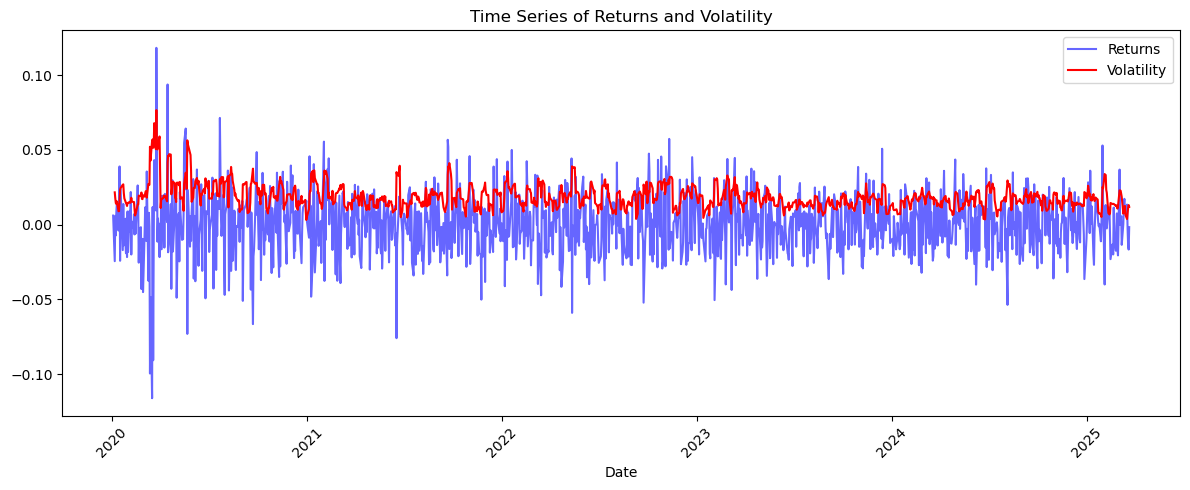

In [495]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Returns', data=plat_df, label='Returns', color='blue',alpha=0.6)
sns.lineplot(x='Date', y='Volatility', data=plat_df, label='Volatility', color='red')


plt.xlabel('Date')
plt.ylabel('')
plt.title('Time Series of Returns and Volatility')
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

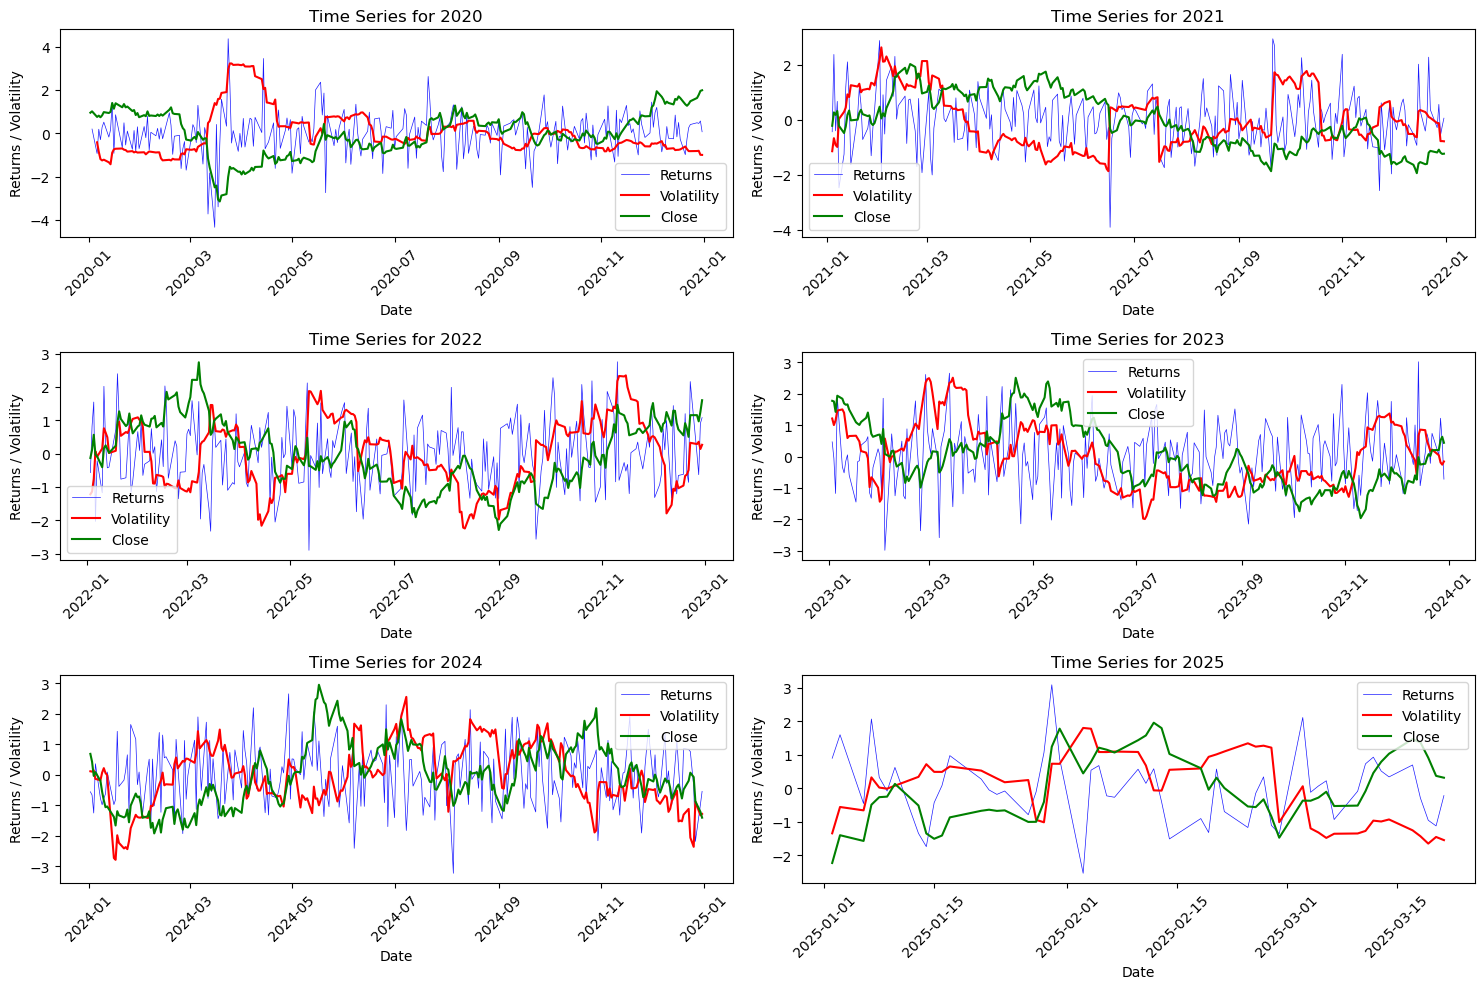

In [542]:
years = [2020, 2021, 2022, 2023, 2024, 2025]


plt.figure(figsize=(15, 10))


for i, year in enumerate(years):
   
    year_data = plat_df[plat_df['Date'].dt.year == year]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["Close","Volatility","Returns"]])
    
    
    ax1 = plt.subplot(3, 2, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    
   
    
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {year}')
    
   
    
    
    
    ax1.legend(loc='best')
   
    
    
    ax1.tick_params(axis='x', rotation=45)


plt.tight_layout()


plt.show()


<Figure size 1500x1000 with 0 Axes>

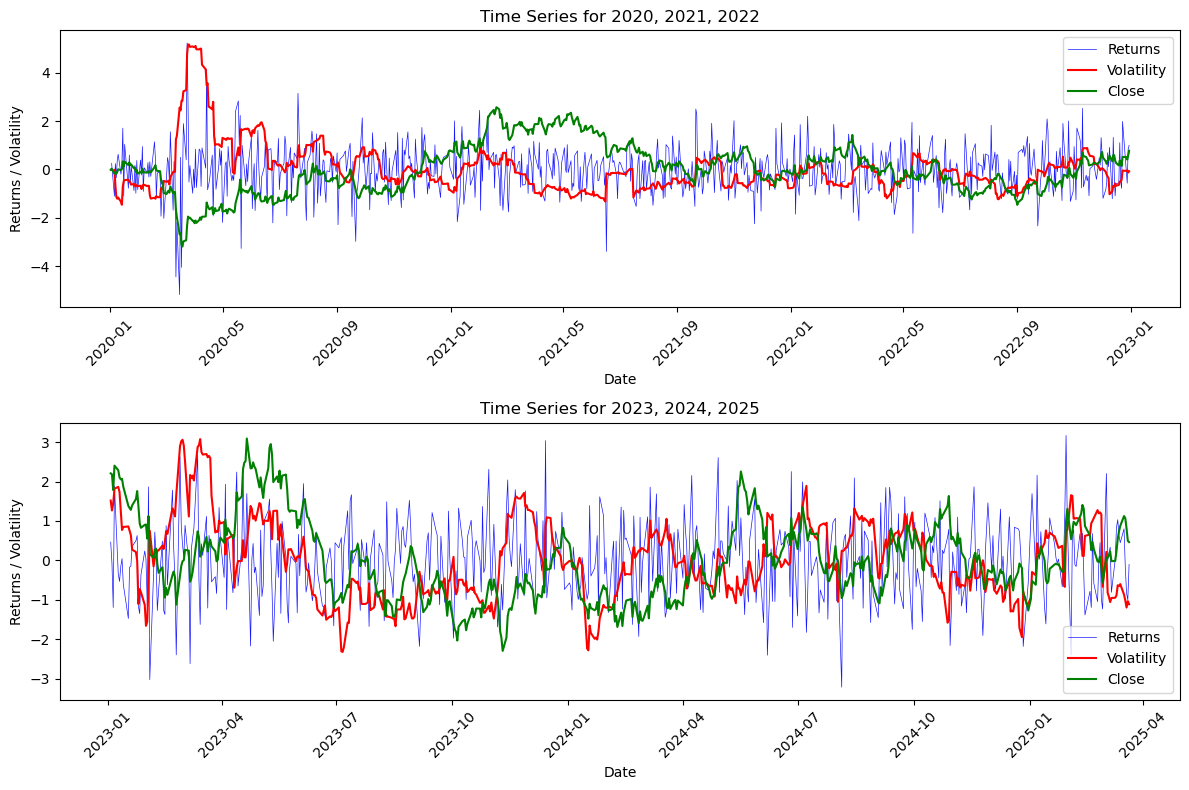

In [554]:
# Create a figure with subplots (2 rows, 1 column)
plt.figure(figsize=(15, 10))

# List of years for each plot
years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

years = [years_1,years_2]


plt.figure(figsize=(12, 8))


for i, year in enumerate(years):
   
    year_data = plat_df[plat_df['Date'].dt.year.isin(year)]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["Close","Volatility","Returns"]])
    
    
    ax1 = plt.subplot(2, 1, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    
   
    
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {(', ').join([str(x) for x in year])}')
    
   
    
    
    
    ax1.legend(loc='best')
   
    
    
    ax1.tick_params(axis='x', rotation=45)


plt.tight_layout()


plt.show()


In [576]:

plat_df.loc[:,'Stationary_Volatility'] = plat_df.loc[:,'Volatility'].diff().fillna(0)

In [555]:
# Create combination dataframe
master_df = plat_df.iloc[:,:-2].merge(dxy[['Date', 'Close']], how='left', on='Date')
master_df = master_df.merge(effr[['observation_date', 'EFFR']], how='left', left_on='Date', right_on='observation_date')

# Drop the redundant observation_date column from effr
master_df = master_df.drop(columns=['observation_date'])
# rename dxy column
master_df.rename(columns={'Close_y':'dxy_close'},inplace=True)
master_df['Year'] = master_df.Date.dt.year


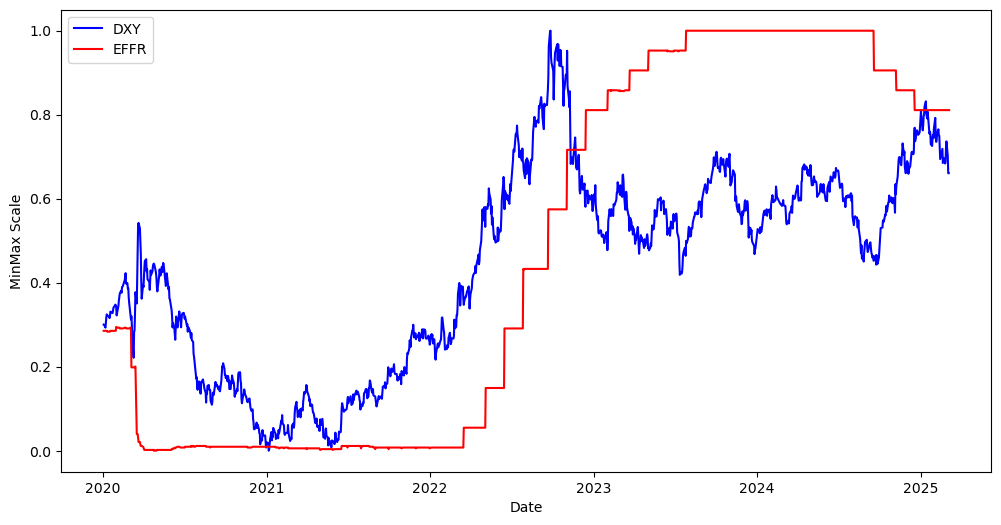

In [556]:
scaler = MinMaxScaler()
years = [2020, 2021, 2022, 2023, 2024, 2025]

filtered_df = master_df[master_df['Year'].isin(years)]
filtered_df.loc[:, ['dxy_scaled', 'effr_scaled']] = scaler.fit_transform(
    filtered_df.loc[:, ['dxy_close', 'EFFR']]
)

plt.figure(figsize=(12, 6))


sns.lineplot(data=filtered_df, x='Date', y='dxy_scaled', color='blue', label='DXY')
sns.lineplot(data=filtered_df, x='Date', y='effr_scaled', color='red', label='EFFR')


plt.legend(loc='upper left')
plt.ylabel('MinMax Scale')
plt.show()


In [603]:
df2 = pd.read_csv('Analysis/precious_metals.csv')
df2['Date'] = pd.to_datetime(df2['Date'])


In [608]:
# filter for Date, Close, Volume
metals = df2.filter(regex='Date|Close|Volume')

# calculate log return from each closing price
metals_log_return = np.log(metals.filter(like='Close').divide(metals.filter(like='Close').shift(1)))
metals_log_return.columns = [x + ' Log Return' for x in metals_log_return.columns.to_list()]

# concat original metals with log returns
metals = pd.concat([metals,metals_log_return],axis=1)

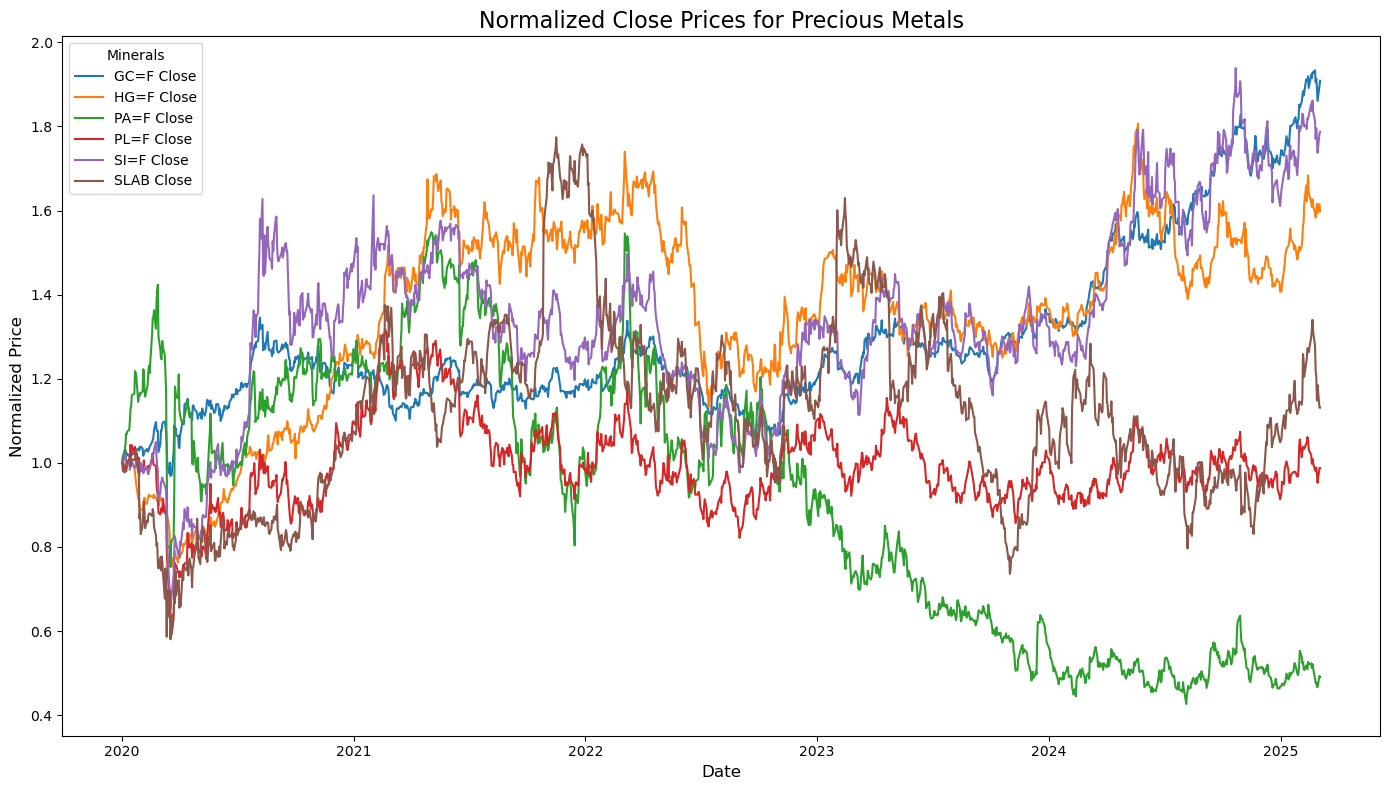

In [675]:
# Normalize the Close prices by dividing by the first value of each series
normalized_df = metals[['Date','GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close', 'SLAB Close']].copy()

# Normalize each column by dividing by its first value
normalized_df.iloc[:,1:] = normalized_df.iloc[:,1:] / normalized_df.iloc[:,1:].iloc[0]

normalized_df_melt = pd.melt(normalized_df,id_vars=['Date'],var_name='Ticker',value_name='Normalized Close')

# Plotting the normalized Close prices
plt.figure(figsize=(14, 8))

sns.lineplot(data=normalized_df_melt,x='Date',y='Normalized Close',hue='Ticker')

# Adding title and labels
plt.title('Normalized Close Prices for Precious Metals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(title="Minerals", loc="upper left")

plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
metals['Year'] = metals.Date.dt.year
metals['Month'] = metals.Date.dt.month_name()

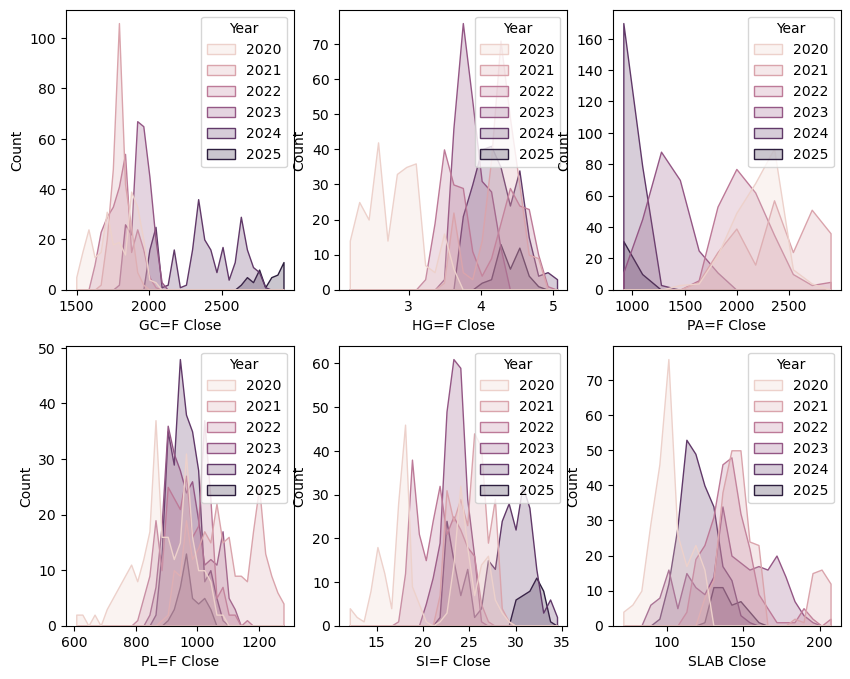

In [ ]:
# cols = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close',
#        'SI=F Close', 'SLAB Close']
# fig,axs = plt.subplots(2,3,figsize=(10,8))
# axs = axs.flatten()
# for i, ticker in enumerate(cols): 
#     sns.histplot(data=metals,x=ticker,hue='Year',element='poly',ax=axs[i])


In [676]:
import seaborn.objects as so

In [613]:

# Number of lags we want to create
max_lags = 10

# List of minerals
minerals = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close', 'SLAB Close']

lag_returns_df = pd.DataFrame()
# Create lagged returns for each mineral
for mineral in minerals:
    for lag in range(1, max_lags + 1):
        lag_returns_df[f'{mineral}_returns_lag_{lag}'] = metals[mineral].pct_change(lag,fill_method=None)

# Display the first few rows to confirm
print(lag_returns_df.shape)


(1299, 60)


In [623]:
# Calculate correlations between returns and lagged returns
correlations = {}

for mineral in minerals:
    for lag in range(1, max_lags + 1):
        lag_column = f'{mineral}_returns_lag_{lag}'
        correlations[mineral+ ' vs ' + mineral + f'_returns_lag_{lag}'] = pd.concat([metals[mineral],lag_returns_df[lag_column]],axis=1).dropna().corr().values[0][1]

# Display the correlation matrix
top_correlations = sorted(correlations.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top Correlations between Mineral Return and Lagged Mineral Return')
top_correlations


Top Correlations between Mineral Return and Lagged Mineral Return


[('PL=F Close vs PL=F Close_returns_lag_10', 0.261660595527357),
 ('PL=F Close vs PL=F Close_returns_lag_9', 0.2523054863538793),
 ('PL=F Close vs PL=F Close_returns_lag_8', 0.24244446585025514),
 ('PL=F Close vs PL=F Close_returns_lag_7', 0.23079752189458946),
 ('SLAB Close vs SLAB Close_returns_lag_10', 0.2182052061672598),
 ('PL=F Close vs PL=F Close_returns_lag_6', 0.2174316973710183),
 ('SLAB Close vs SLAB Close_returns_lag_9', 0.20672015691651044),
 ('PL=F Close vs PL=F Close_returns_lag_5', 0.2013894950448125),
 ('GC=F Close vs GC=F Close_returns_lag_10', 0.19907372275359791),
 ('SLAB Close vs SLAB Close_returns_lag_8', 0.19319201347893455),
 ('GC=F Close vs GC=F Close_returns_lag_9', 0.18758348881794906),
 ('PL=F Close vs PL=F Close_returns_lag_4', 0.1812079671444416),
 ('SLAB Close vs SLAB Close_returns_lag_7', 0.17971068113400046),
 ('GC=F Close vs GC=F Close_returns_lag_8', 0.17506934436154475),
 ('PA=F Close vs PA=F Close_returns_lag_10', 0.1745155166297378),
 ('SI=F Close 

In [630]:
for mineral in minerals:
    metals[f'{mineral}_daily_pct_change'] = metals[mineral].pct_change(fill_method=None)

In [634]:
growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "SQ",    # Square, Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU"   # DocuSign, Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

In [636]:
# Combine both lists of stocks
all_stocks = growth_stocks + value_stocks

# Define the date range for the stock data download (from 2020 to now)
start_date = "2020-01-01"
end_date = "2025-03-04"

# download stocks
stock_data = yf.download(all_stocks, start=start_date, end=end_date, progress=False)['Close']
#calculate log returns
stock_returns_df = np.log(stock_data.divide(stock_data.shift(1),axis=0))

# rename columns and set Date column
stock_returns_df.columns = [col+"_log_return" for col in stock_returns_df.columns.to_list()]
stock_returns_df.reset_index(names='Date',inplace=True)

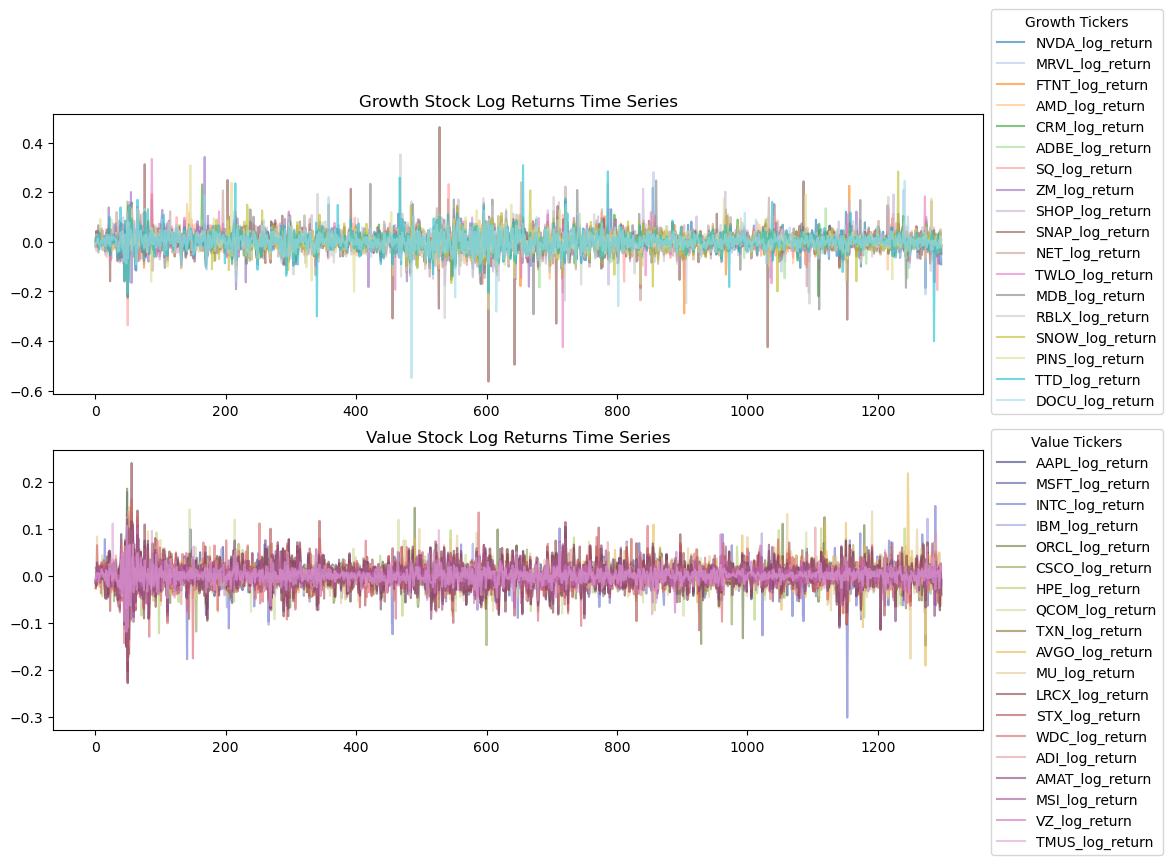

In [637]:
# Plotting the time series for each stock ticker (log returns) in the stock_returns_df

fig,axs = plt.subplots(2,1,figsize=(12,8))

stock_returns_df.loc[:,[col+"_log_return" for col in growth_stocks]].plot(cmap='tab20',ax=axs[0],alpha=0.6)

stock_returns_df.loc[:,[col+"_log_return" for col in value_stocks]].plot(cmap='tab20b',ax=axs[1],alpha=0.6)

axs[0].set_title('Growth Stock Log Returns Time Series')
axs[0].legend(title='Growth Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.4))

axs[1].set_title('Value Stock Log Returns Time Series')
axs[1].legend(title='Value Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.1))


plt.show()

In [641]:
# List of columns for the different groups
minerals_columns = [
    'GC=F Log Return', 'HG=F Log Return', 'PA=F Log Return', 'PL=F Log Return', 'SI=F Log Return', 'SLAB Log Return'
]

stock_columns = [
    'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'AMD_log_return', 'CRM_log_return',
    'ADBE_log_return', 'SQ_log_return', 'ZM_log_return', 'SHOP_log_return', 'SNAP_log_return',
    'NET_log_return', 'TWLO_log_return', 'MDB_log_return', 'RBLX_log_return', 'SNOW_log_return',
    'PINS_log_return', 'TTD_log_return', 'DOCU_log_return', 'AAPL_log_return', 'MSFT_log_return',
    'INTC_log_return', 'IBM_log_return', 'ORCL_log_return', 'CSCO_log_return', 'HPE_log_return',
    'QCOM_log_return', 'TXN_log_return', 'AVGO_log_return', 'MU_log_return', 'LRCX_log_return',
    'STX_log_return', 'WDC_log_return', 'ADI_log_return', 'AMAT_log_return', 'MSI_log_return',
    'VZ_log_return', 'TMUS_log_return'
]

master_df1 = pd.merge(plat_df[['Date','Volatility'] + minerals_columns], stock_returns_df, on='Date', how='left') 
# Set 'Date' as the index
master_df1.set_index('Date', inplace=True)

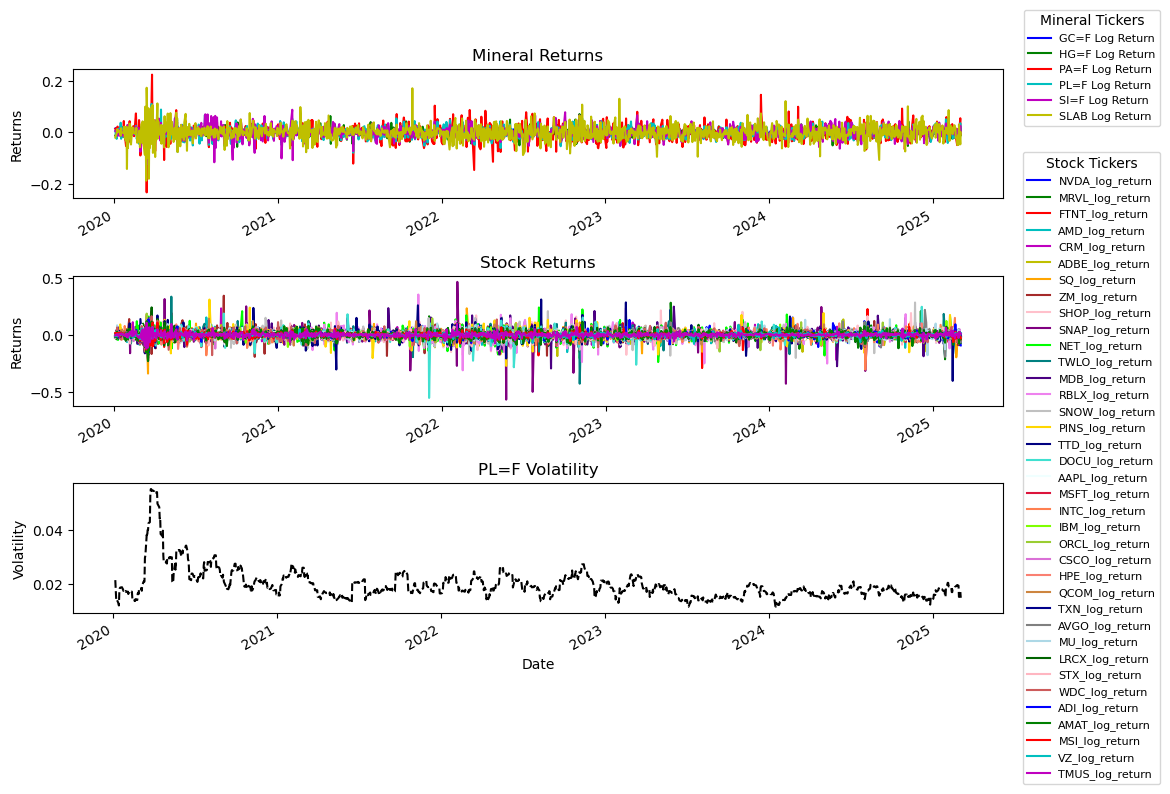

In [643]:
volatility_column = 'Volatility'

# Plotting the time series for minerals, stocks, and volatility
plt.figure(figsize=(14, 10))

# Plot mineral returns
plt.subplot(3, 1, 1)
master_df1[minerals_columns].plot(figsize=(12, 8), ax=plt.gca(), title="Mineral Returns", color=['b', 'g', 'r', 'c', 'm', 'y'])
plt.legend(minerals_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.175, 1.5),fontsize=8)
plt.ylabel('Returns')
plt.xlabel('')

# Plot stock returns
plt.subplot(3, 1, 2)
master_df1[stock_columns].plot(figsize=(12, 8), ax=plt.gca(),legend=False, title="Stock Returns",
                               color=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet',
                                      'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid',
                                      'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink', 'indianred'])
plt.legend(stock_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.175, 2),fontsize=8)
plt.ylabel('Returns')
plt.xlabel('')

# Plot volatility
plt.subplot(3, 1, 3)
master_df1[volatility_column].plot(figsize=(12, 8), ax=plt.gca(), title="PL=F Volatility", color='black', linestyle='--')
plt.ylabel('Volatility')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.6)

plt.show()


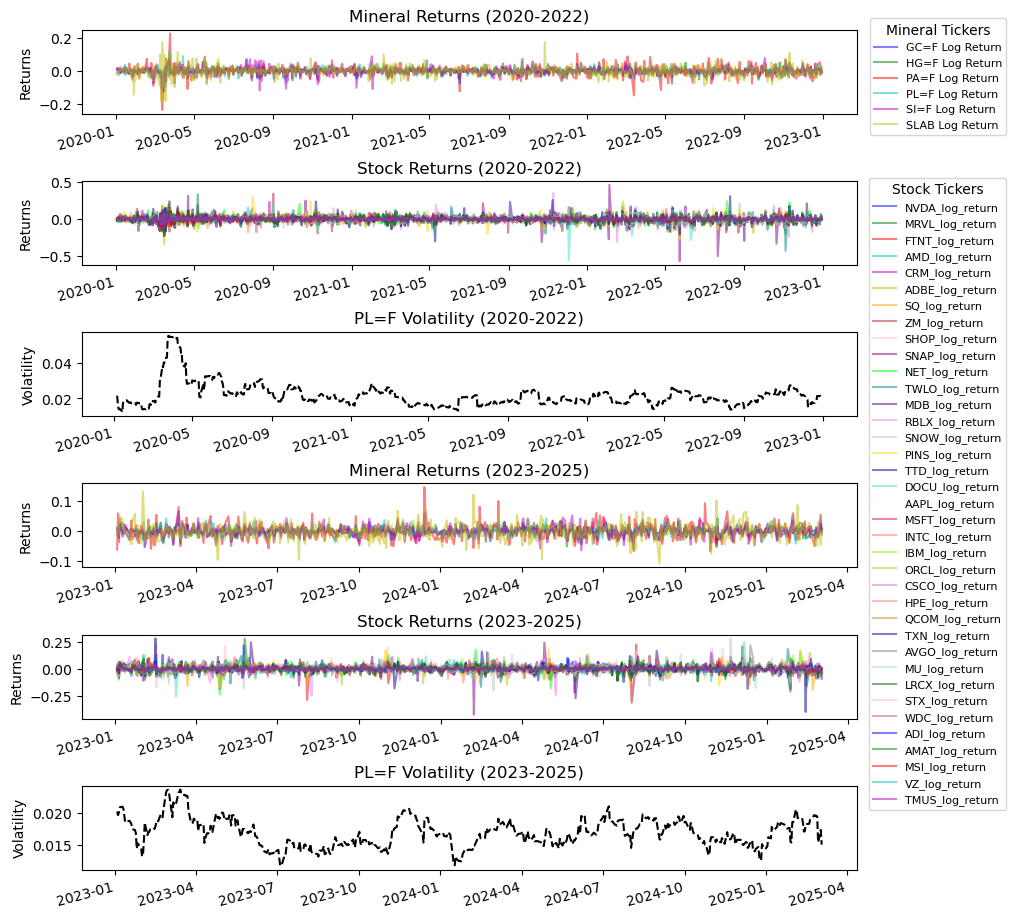

In [648]:

# Define the date ranges
start_date_1 = '2020-01-01'
end_date_1 = '2022-12-31'
start_date_2 = '2023-01-01'
end_date_2 = '2025-12-31'

# Filter data for the two periods
df_2020_2022 = master_df1.loc[start_date_1:end_date_1]
df_2023_2025 = master_df1.loc[start_date_2:end_date_2]

# Plotting the time series for minerals, stocks, and volatility for 2020-2022
colors=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet', 'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid', 'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink', 'indianred']

# fig, axs = plt.subplots()
# plt.figure(figsize=(18, 7))

# Plot mineral returns (2020-2022)
axs1 = plt.subplot(6, 1, 1)
df_2020_2022[minerals_columns].plot(figsize=(12, 8), ax=axs1, title="Mineral Returns (2020-2022)", color=['b', 'g', 'r', 'c', 'm', 'y'],alpha=0.5)
plt.legend(minerals_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.2),fontsize=8)
plt.xlabel('')
plt.ylabel('Returns')
axs1.tick_params(axis='x', rotation=15)


# Plot stock returns (2020-2022)
axs2 = plt.subplot(6, 1, 2)
df_2020_2022[stock_columns].plot(figsize=(12, 8), ax=axs2, title="Stock Returns (2020-2022)", color=colors,alpha=0.5)
plt.legend(stock_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.1),fontsize=8)
plt.xlabel('')
plt.ylabel('Returns')
axs2.tick_params(axis='x', rotation=15)

# Plot volatility (2020-2022)
axs3 = plt.subplot(6, 1, 3)
df_2020_2022[volatility_column].plot(figsize=(10, 7), ax=axs3, title="PL=F Volatility (2020-2022)", color='black', linestyle='--')
plt.xlabel('')
plt.ylabel('Volatility')
axs3.tick_params(axis='x', rotation=15)

# Plotting the time series for minerals, stocks, and volatility for 2023-2025
# Plot mineral returns (2023-2025)
axs4 = plt.subplot(6, 1, 4)
df_2023_2025[minerals_columns].plot(figsize=(10, 7), ax=axs4, title="Mineral Returns (2023-2025)", color=['b', 'g', 'r', 'c', 'm', 'y'],legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs4.tick_params(axis='x', rotation=15)

# Plot stock returns (2023-2025)
axs5 = plt.subplot(6, 1, 5)
df_2023_2025[stock_columns].plot(figsize=(10, 7), ax=axs5, title="Stock Returns (2023-2025)",color=colors,legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs5.tick_params(axis='x', rotation=15)

# Plot volatility (2023-2025)
axs6=plt.subplot(6, 1, 6)
df_2023_2025[volatility_column].plot(figsize=(10, 7), ax=axs6, title="PL=F Volatility (2023-2025)", color='black', linestyle='--',legend=False)
plt.ylabel('Volatility')
plt.xlabel('')
axs6.tick_params(axis='x', rotation=15)

plt.subplots_adjust(left=None, right=None, 
                    top=1.7, bottom=.5, 
                    wspace=0.4, hspace=0.8)

plt.show()


In [649]:
# Define lag range (1-10)
lags = range(1, 11)

# Function to create lagged features for minerals
def create_lagged_df(df, columns, lags):
    lagged_df = pd.DataFrame()
    for col in columns:
        for lag in lags:
            lagged_df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return lagged_df

# Create lagged columns for the minerals
lagged_minerals_df = create_lagged_df(master_df1, minerals_columns, lags)
lagged_minerals_df.head()

,GC=F Log Return_lag_1,GC=F Log Return_lag_2,GC=F Log Return_lag_3,GC=F Log Return_lag_4,GC=F Log Return_lag_5,GC=F Log Return_lag_6,GC=F Log Return_lag_7,GC=F Log Return_lag_8,GC=F Log Return_lag_9,GC=F Log Return_lag_10,...,SLAB Log Return_lag_1,SLAB Log Return_lag_2,SLAB Log Return_lag_3,SLAB Log Return_lag_4,SLAB Log Return_lag_5,SLAB Log Return_lag_6,SLAB Log Return_lag_7,SLAB Log Return_lag_8,SLAB Log Return_lag_9,SLAB Log Return_lag_10
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.016072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.019787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,0.010914,0.016072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.003279,-0.019787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,0.003569,0.010914,0.016072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.012710,-0.003279,-0.019787,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [658]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, pacf, acf

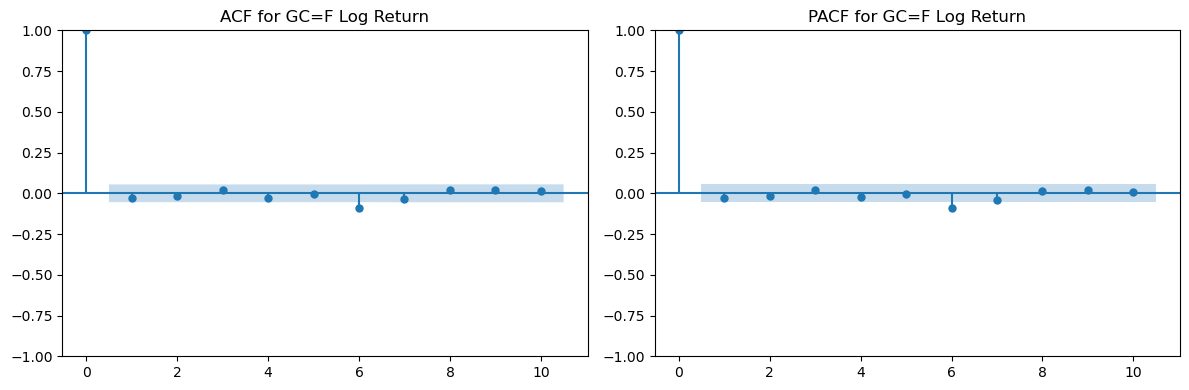

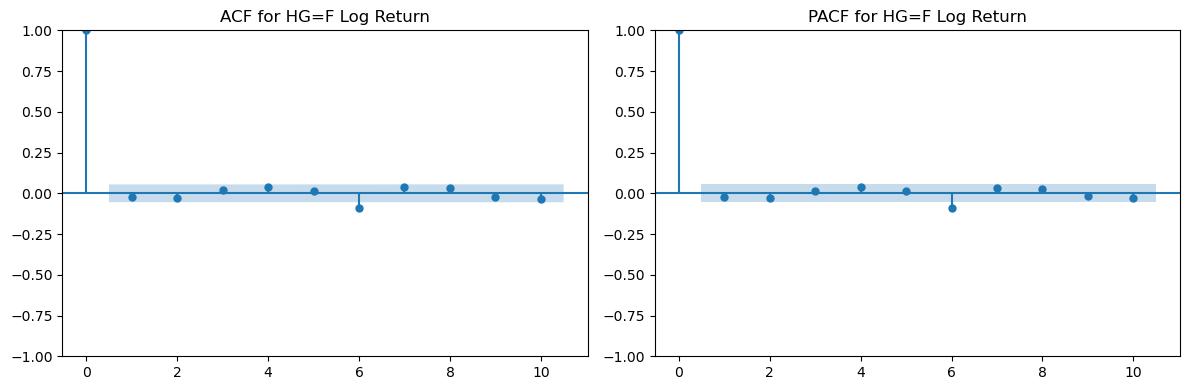

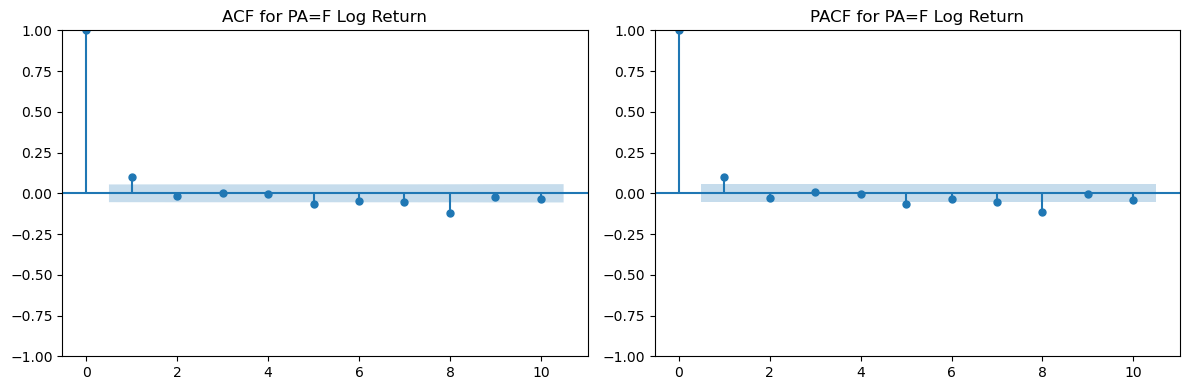

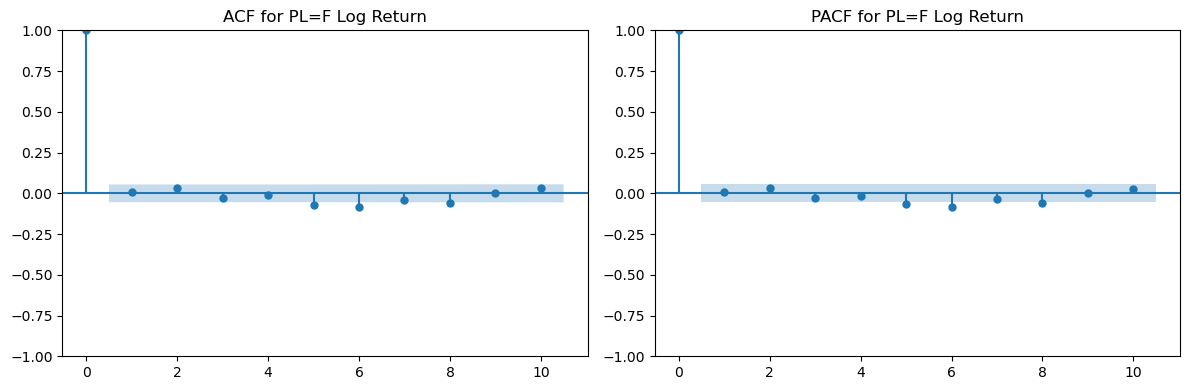

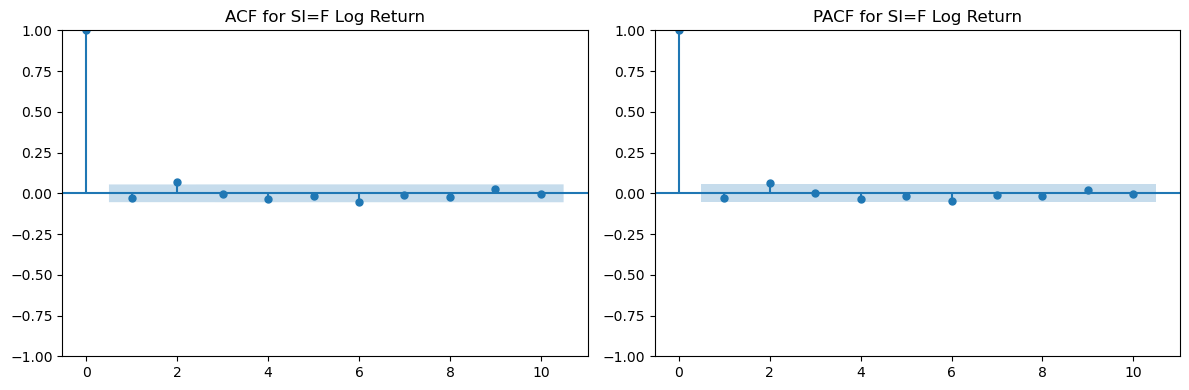

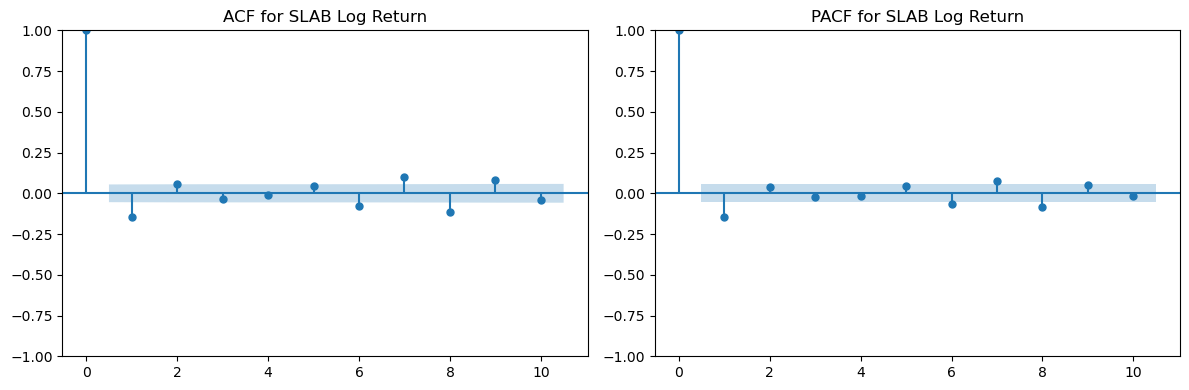

In [652]:
# Loop through each mineral column and plot ACF/PACF directly
for mineral in minerals_columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    sm.graphics.tsa.plot_acf(master_df1[mineral].dropna(), lags=10, ax=axs[0])
    axs[0].set_title(f'ACF for {mineral}')
    
    sm.graphics.tsa.plot_pacf(master_df1[mineral].dropna(), lags=10, ax=axs[1])
    axs[1].set_title(f'PACF for {mineral}')
    
    plt.tight_layout()
    plt.show()


In [653]:
# Ensure the indices align between the lagged mineral dataframe and master_df1
lagged_minerals_df = lagged_minerals_df.sort_index()
master_df1 = master_df1.sort_index()

In [411]:
#I want the correlation between  each stock in stock columns and each mineral in lagged df
### at each lag, I check if there is a correlation between the log return of a stock


In [ ]:
# Prepare an empty DataFrame to store the ACF/PACF results
correlation_results = {}


# Loop over each lagged mineral column (in lagged_minerals_df) and each stock column to compute ACF and PACF
for mineral_col in lagged_minerals_df.columns:  # Using columns in lagged_minerals_df
    for stock_col in stock_columns:
        # Drop NaN values from both series to ensure proper alignment
        mineral_series = lagged_minerals_df[mineral_col].dropna()  # Get the lagged series
        stock_series = master_df1[stock_col].dropna()  # Get the stock log returns
        
        # Ensure the series are aligned by their indices
        aligned_data = pd.concat([mineral_series, stock_series], axis=1).dropna()
        mineral_series = aligned_data[mineral_col]
        stock_series = aligned_data[stock_col]
        
        # Calculate ACF and PACF between lagged mineral and stock returns
        lag_correlation = np.corrcoef(mineral_series, stock_series)[:1,1][0]
        
        # Store the results
        correlation_results[f'{mineral_col} vs {stock_col}'] = lag_correlation
       


top_corr = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)[:8]



top_corr


[('SLAB Log Return_lag_1 vs TXN_log_return', -0.16731728228215734),
 ('SLAB Log Return_lag_1 vs TMUS_log_return', -0.15514185185569346),
 ('SLAB Log Return_lag_1 vs ADI_log_return', -0.14879483946354918),
 ('SLAB Log Return_lag_1 vs ADBE_log_return', -0.13787798546126465),
 ('SLAB Log Return_lag_1 vs MSFT_log_return', -0.1372582992030339),
 ('SLAB Log Return_lag_8 vs LRCX_log_return', -0.13519137585388702),
 ('SLAB Log Return_lag_1 vs QCOM_log_return', -0.13288332453258253),
 ('PL=F Log Return_lag_2 vs TMUS_log_return', 0.13288074374901027)]

In [327]:
# Create lagged volume and volatility columns up to 5 lags
lags = 5
lagged_volatility_columns = ['Volatility']
lagged_volume_columns = [
    'GC=F Volume', 'HG=F Volume', 'PA=F Volume', 'PL=F Volume', 'SI=F Volume', 'SLAB Volume'
]

# Create a DataFrame to hold lagged values
lagged_minerals_df = pd.DataFrame()

# Create lagged volumes
for col in lagged_volume_columns:
    for lag in range(1, lags + 1):
        lagged_minerals_df[f'{col}_lag_{lag}'] = df2[col].shift(lag)

# Create lagged volatility
for lag in range(1, lags + 1):
    lagged_minerals_df[f'Volatility_lag_{lag}'] = master_df1['Volatility'].shift(lag)

# Display the first few rows of the DataFrame to ensure the lagged columns are correctly created
lagged_minerals_df.head()


,GC=F Volume_lag_1,GC=F Volume_lag_2,GC=F Volume_lag_3,GC=F Volume_lag_4,GC=F Volume_lag_5,HG=F Volume_lag_1,HG=F Volume_lag_2,HG=F Volume_lag_3,HG=F Volume_lag_4,HG=F Volume_lag_5,...,SLAB Volume_lag_1,SLAB Volume_lag_2,SLAB Volume_lag_3,SLAB Volume_lag_4,SLAB Volume_lag_5,Volatility_lag_1,Volatility_lag_2,Volatility_lag_3,Volatility_lag_4,Volatility_lag_5
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,214.0,NaN,NaN,NaN,NaN,1182.0,NaN,NaN,NaN,NaN,...,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107.0,214.0,NaN,NaN,NaN,321.0,1182.0,NaN,NaN,NaN,...,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,416.0,107.0,214.0,NaN,NaN,333.0,321.0,1182.0,NaN,NaN,...,232900.0,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,47.0,416.0,107.0,214.0,NaN,261.0,333.0,321.0,1182.0,NaN,...,147900.0,232900.0,157100.0,162600.0,NaN,NaN,NaN,NaN,NaN,NaN


In [660]:
# Function to calculate ACF and PACF for a single series
def calculate_acf_pacf(x, lags=8):
    x_values = x.values.flatten() 
    lags = int(lags)
    
    # Calculate ACF and PACF using numpy arrays
    acf_vals = acf(x_values, nlags=lags, adjusted=True)  # Only use adjusted (no fft)
    pacf_vals = pacf(x_values, nlags=lags)  # Removed adjusted argument as it is not accepted now
    
    return acf_vals, pacf_vals

# Now calculate ACF and PACF for each interaction term with stock returns
acf_results = {}
pacf_results = {}


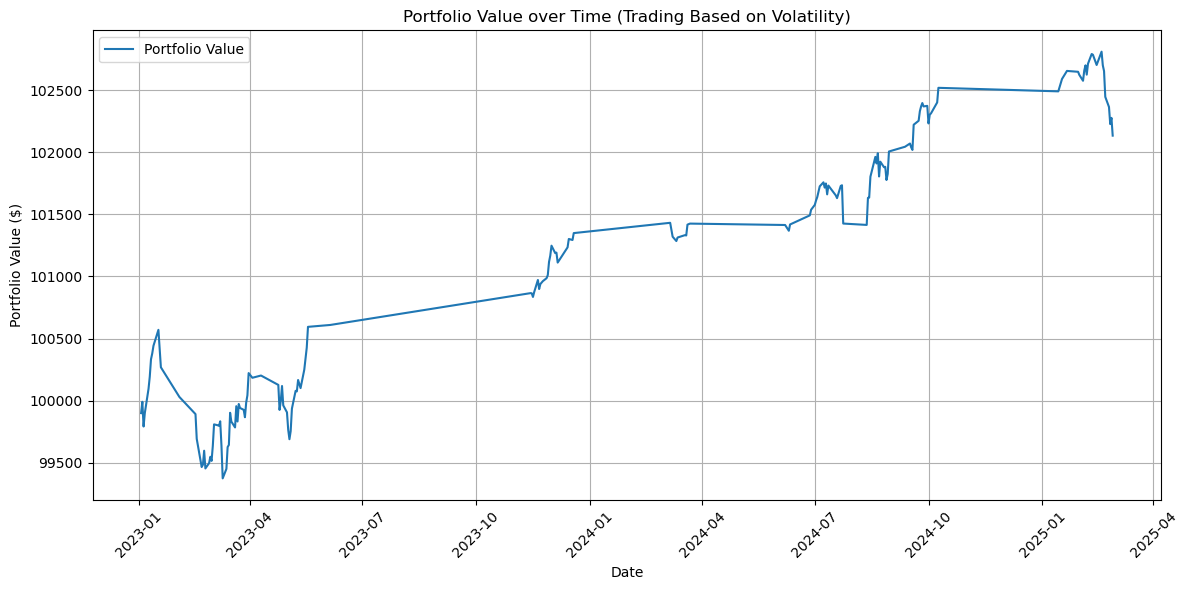

In [670]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['Volatility']
    if np.isnan(volatility):
        continue
  
    if volatility < np.percentile(test_data['Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment_pct * portfolio_value)  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        if pd.isna(row[stock]):
            continue

        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Update portfolio based on the return for this stock (assuming buying)
        portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
        portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
        
        trade_history.append({
            'date': row.name,
            'action': 'Buy',
            'stock': stock,
            'investment': investment_per_stock,
            'portfolio_value': portfolio_value,
            'return_pct': stock_return * 100,
            'gain_loss': investment_per_stock * stock_return

        })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


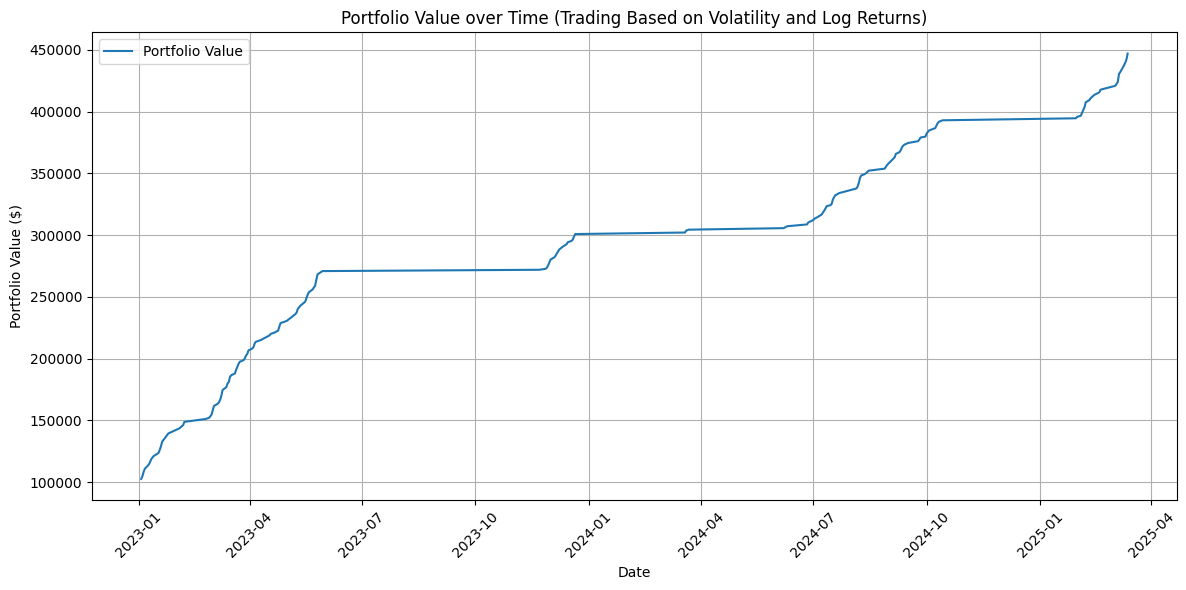

In [ ]:

# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  # Max 6% of portfolio per stock

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment * len(stocks_to_buy))  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


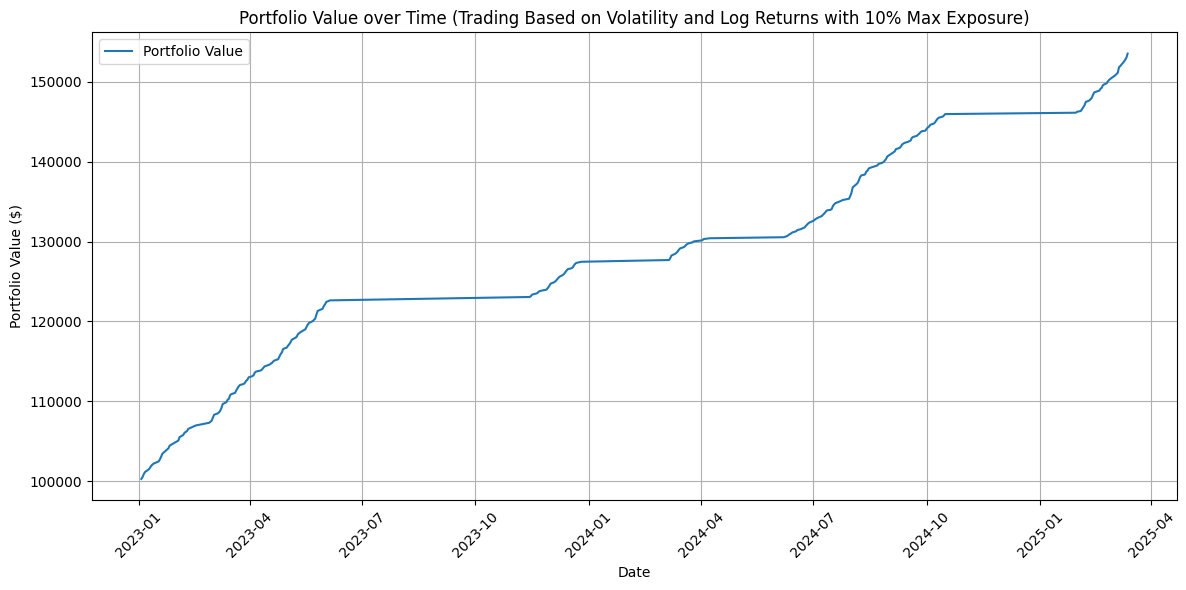

In [ ]:


# Initialize parameters for the strategy
volatility_threshold_pct = 0.55  # Top 30% volatility for trading
max_investment_pct = 0.1  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns with 10% Max Exposure)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


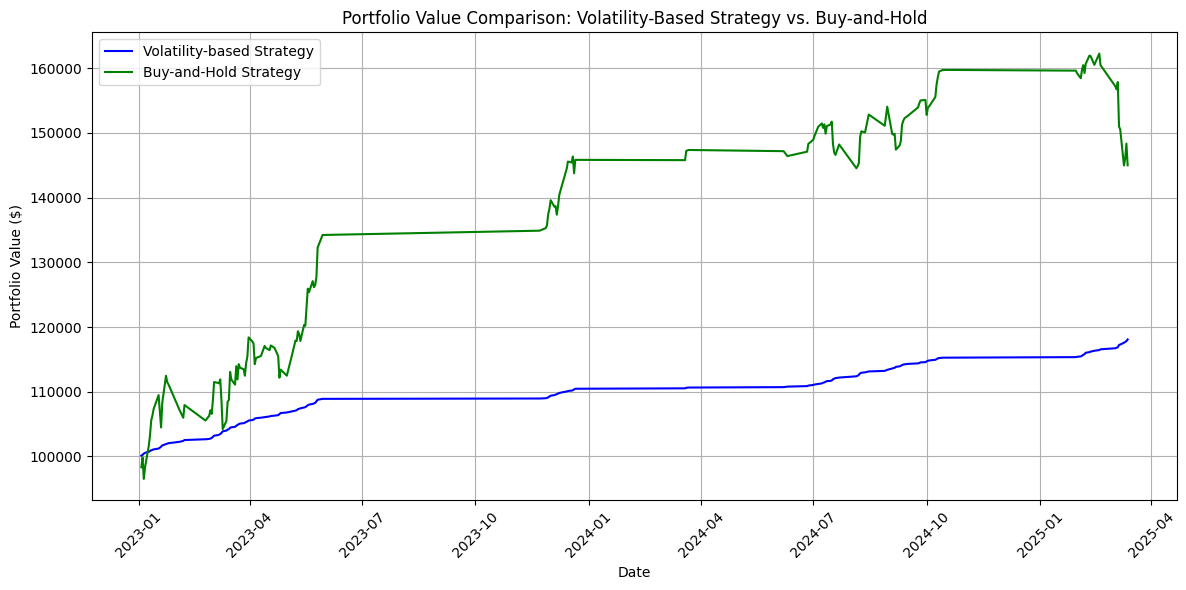

Volatility-Based Strategy Volatility: 0.0005
Buy-and-Hold Strategy Volatility: 0.0151
Volatility-Based Strategy Sharpe Ratio: 2.0208
Buy-and-Hold Strategy Sharpe Ratio: 0.1546


In [ ]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility: {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio: {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")


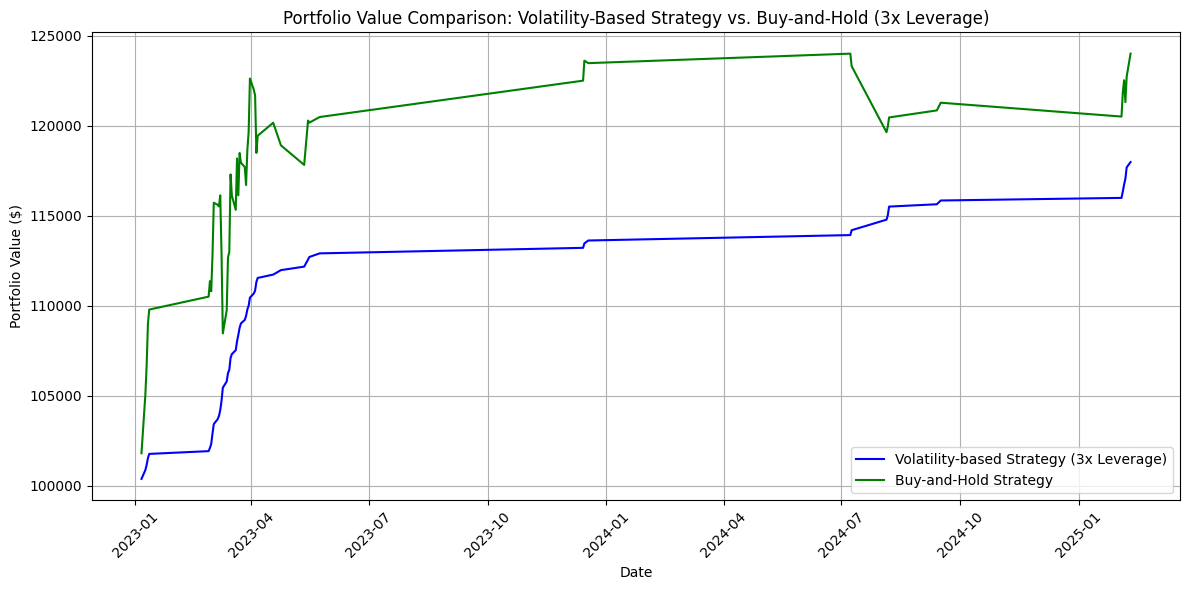

Volatility-Based Strategy Volatility (3x Leverage): 0.0014
Buy-and-Hold Strategy Volatility: 0.0152
Volatility-Based Strategy Sharpe Ratio (3x Leverage): 2.1297
Buy-and-Hold Strategy Sharpe Ratio: 0.2362


In [ ]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.9  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 5% of the portfolio
leverage_factor = 3  # 3x leverage

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = master_df1[master_df1.index <= '2022-12-31']
test_data = master_df1[master_df1.index >= '2023-01-01']

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (5% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 5% of portfolio, with leverage)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 5% daily exposure
    total_investment_with_leverage = total_investment * leverage_factor  # Apply 3x leverage

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment_with_leverage / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy (3x Leverage)", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold (3x Leverage)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility (3x Leverage): {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio (3x Leverage): {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")
